In [1]:
import os
import sys

# Comprobamos si estamos en Google Colab
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Entorno Colab detectado. Montando Google Drive...")
    drive.mount('/content/drive')
    # Ajustar esta ruta según la carpeta que se encuentre en Drive
    ruta_proyecto = '/content/drive/MyDrive/RetinaScan-UNet' 
    if os.path.exists(ruta_proyecto):
        os.chdir(ruta_proyecto)
    else:
        print(f"Ruta no encontrada: {ruta_proyecto}. Por favor, ajústala.")
else:
    print("Entorno local detectado.")
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")

sys.path.insert(0, os.path.join(os.getcwd(), "src"))
print("Directorio de trabajo actual:", os.getcwd())

Entorno local detectado.
Directorio de trabajo actual: C:\Users\maarc\Desktop\TERCERO_SOFTWARE\SEGUNDO CUATRI\IA\PROYECTO\retina_workspace\RetinaScan-UNet


In [2]:
import cv2
import glob
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt


from metrics import dice_coef, dice_loss, bce_dice_loss

In [3]:
patch_size = (128, 128)
models_dir = "models"

def leer_img(ruta):
    img = cv2.imread(ruta, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    img = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
    return img.astype(np.float32) / 255.0

def leer_mascara(ruta):
    mascara = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    return (mascara > 127).astype(np.float32)

def predecir_parches(modelo, img, p_size=(128, 128), stride=64):
    h, w, _ = img.shape
    ph, pw = p_size
    acumulador = np.zeros((h, w), dtype=np.float32)
    contador = np.zeros((h, w), dtype=np.float32)
    filas = list(range(0, h - ph + 1, stride))
    cols = list(range(0, w - pw + 1, stride))
    if not filas: filas = [0]
    if not cols: cols = [0]
    if filas[-1] + ph < h: filas.append(h - ph)
    if cols[-1] + pw < w: cols.append(w - pw)
    parches = []
    coords = []
    for r in filas:
        for c in cols:
            parches.append(img[r:r+ph, c:c+pw, :])
            coords.append((r, c))
    parches = np.array(parches, dtype=np.float32)
    preds = modelo.predict(parches, verbose=0, batch_size=16)
    for i, (r, c) in enumerate(coords):
        acumulador[r:r+ph, c:c+pw] += preds[i, :, :, 0]
        contador[r:r+ph, c:c+pw] += 1.0
    contador[contador == 0] = 1.0
    return acumulador / contador

def calcular_dice(pred, mask):
    inter = np.sum(pred * mask)
    denominador = np.sum(pred) + np.sum(mask)
    if denominador == 0: return 1.0
    return (2.0 * inter + 1e-6) / (denominador + 1e-6)

print("Cargando el K-Fold Ensemble (5 modelos)...")
rutas = sorted(glob.glob(os.path.join(models_dir, "fold_*.keras")))
modelos_unet = [keras.models.load_model(r, custom_objects={"dice_coef": dice_coef, "dice_loss": dice_loss}) for r in rutas]
print("¡Modelos cargados correctamente!")

Cargando el K-Fold Ensemble (5 modelos)...
¡Modelos cargados correctamente!


In [4]:
def ensemble_predict_tta(modelos, img, p_size=(128, 128), stride=64):
    suma = np.zeros(img.shape[:2], dtype=np.float32)
    img_h = cv2.flip(img, 1)
    img_v = cv2.flip(img, 0)
    
    for m in modelos:
        suma += predecir_parches(m, img, p_size, stride)
        p_h = predecir_parches(m, img_h, p_size, stride)
        suma += cv2.flip(p_h, 1)
        p_v = predecir_parches(m, img_v, p_size, stride)
        suma += cv2.flip(p_v, 0)
        
    return suma / (len(modelos) * 3.0)

Realizando inferencia con TTA para la imagen 15...

RESULTADOS IMAGEN 15:
-> Umbral Otsu automático: 0.4275
-> Umbral tras Offset (-0.040): 0.3875
-> DICE vs Experto 1: 0.7505
-> DICE vs Experto 2: 0.7310
-> DICE MEDIA FINAL:  0.7408


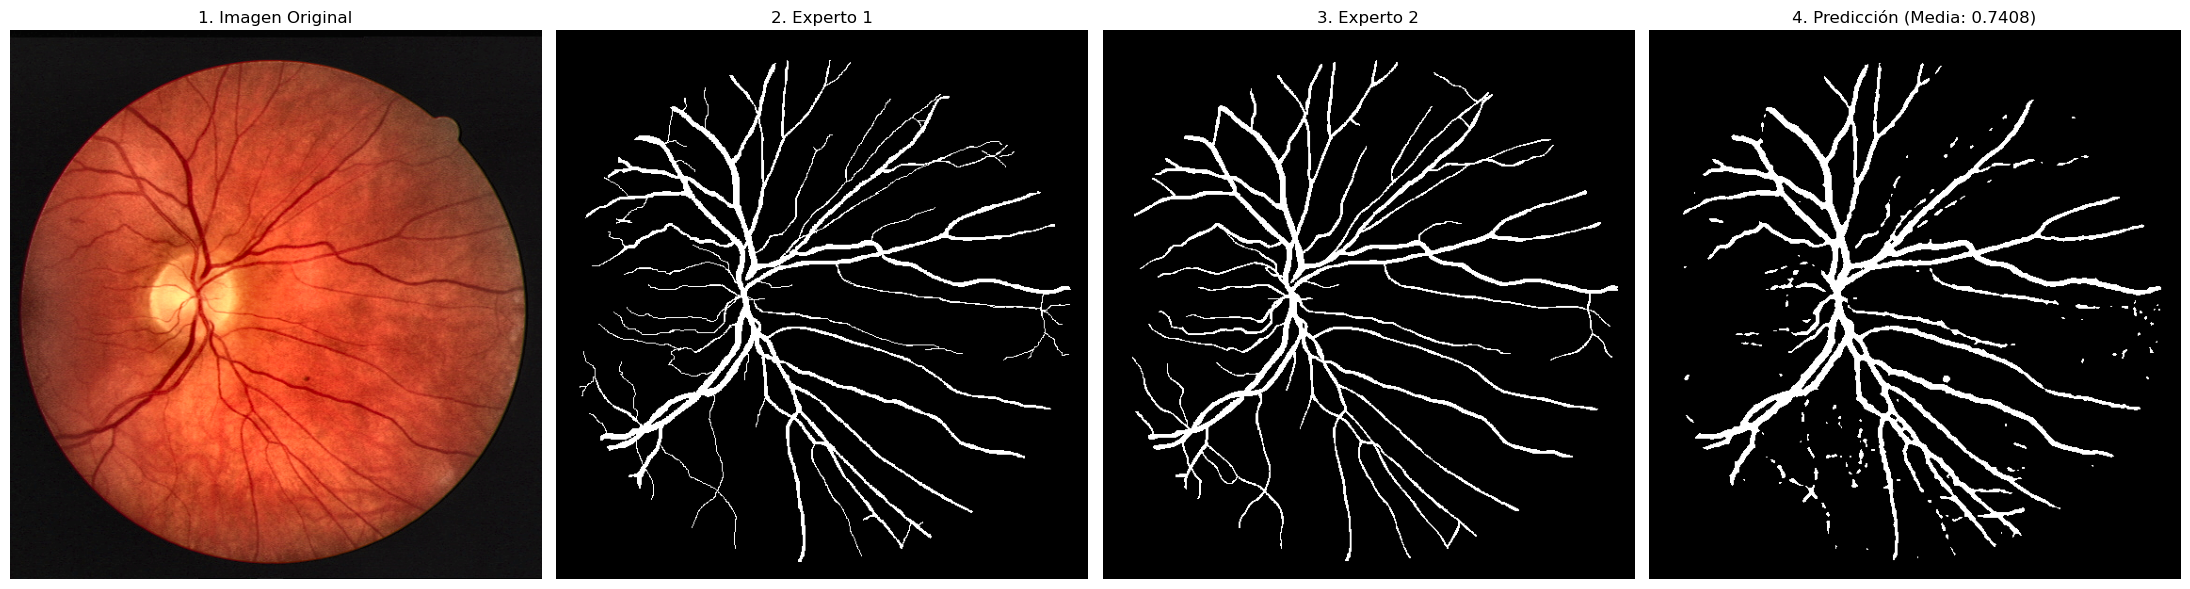

In [11]:
# DEMOSTRACIÓN DE LA IMAGEN 15 (LA PROBLEMÁTICA) Y LA IMAGEN 2 (LA DE MAYOR ÉXITO)
numero_test = "15"  # Cambiar esto a "02" para probar la otra
ruta_imagen = os.path.join("data", "test", "images", f"{numero_test}_test.tif")
ruta_gt1 = os.path.join("data", "test", "1st_manual", f"{numero_test}_manual1.gif")
ruta_gt2 = os.path.join("data", "test", "2nd_manual", f"{numero_test}_manual2.gif")

# 1. Lectura
img_demostracion = leer_img(ruta_imagen)
gt1_demostracion = leer_mascara(ruta_gt1)
gt2_demostracion = leer_mascara(ruta_gt2)

print(f"Realizando inferencia con TTA para la imagen {numero_test}...")
prob = ensemble_predict_tta(modelos_unet, img_demostracion, patch_size, 64)

# 2. Pipeline de Otsu y Morfología
prob_uint8 = (prob * 255).astype(np.uint8)
umbral_otsu_val, _ = cv2.threshold(prob_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
umbral_real = umbral_otsu_val / 255.0

# Offset
umbral_ajustado = max(0, umbral_real - 0.040)
_, pred_uint8 = cv2.threshold(prob_uint8, int(umbral_ajustado * 255), 255, cv2.THRESH_BINARY)

# Cierre Morfológico
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
pred_uint8 = cv2.morphologyEx(pred_uint8, cv2.MORPH_CLOSE, kernel, iterations=1)
pred = (pred_uint8 / 255.0).astype(np.float32)

# Limpieza
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(pred_uint8, connectivity=8)
pred_limpia = np.zeros_like(pred)
for j in range(1, num_labels):
    if stats[j, cv2.CC_STAT_AREA] >= 2:  
        pred_limpia[labels == j] = 1.0
pred = pred_limpia

# 3. Métricas
d1 = calcular_dice(pred, gt1_demostracion)
d2 = calcular_dice(pred, gt2_demostracion)
d_media = (d1 + d2) / 2.0

print(f"\nRESULTADOS IMAGEN {numero_test}:")
print(f"-> Umbral Otsu automático: {umbral_real:.4f}")
print(f"-> Umbral tras Offset (-0.040): {umbral_ajustado:.4f}")
print(f"-> DICE vs Experto 1: {d1:.4f}")
print(f"-> DICE vs Experto 2: {d2:.4f}")
print(f"-> DICE MEDIA FINAL:  {d_media:.4f}")

# 4. Visualización (4 paneles)
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
axes[0].imshow(img_demostracion)
axes[0].set_title("1. Imagen Original")
axes[0].axis("off")

axes[1].imshow(gt1_demostracion, cmap="gray")
axes[1].set_title("2. Experto 1")
axes[1].axis("off")

axes[2].imshow(gt2_demostracion, cmap="gray")
axes[2].set_title("3. Experto 2")
axes[2].axis("off")

axes[3].imshow(pred, cmap="gray")
axes[3].set_title(f"4. Predicción (Media: {d_media:.4f})")
axes[3].axis("off")

plt.tight_layout()
plt.show()